# Shov-JEPA vs Plain JEPA: Fair Comparison
Same architecture, same data, same masking. One difference:
- **Shov-JEPA**: 3D representation (P,F,D) + supervised Shov loss
- **Plain JEPA**: 64D free representation + self-supervised only, then linear probe

~5 min. **Run all**.

In [1]:
%%javascript
function ClickConnect(){ document.querySelector('colab-connect-button')?.click(); }
setInterval(ClickConnect, 60000);

<IPython.core.display.Javascript object>

In [2]:
!pip install datasets -q
import torch, os, json, time, copy
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


## 1. Data (same as v4)

In [3]:
import datasets as dsets
DATA_DIR = '/content/shov_v5'
os.makedirs(DATA_DIR, exist_ok=True)
TARGET = 200; GRID = 4; CELL_FEATS = 8

FUNNEL_P = ['feed','stream','timeline','browse','news','video','media','story','content',
  'discover','explore','watch','recommend','trending','popular','gallery','photo',
  'subreddit','channel','episode','series','article','scroll','swipe','home','main',
  'list','catalog','playlist','player']
DOORS_P = ['setting','config','preference','about','detail','form','edit','add','create',
  'signup','login','auth','register','profile','info','help','faq','terms','privacy',
  'option','permission','tutorial','onboard','welcome','picker','select','choose',
  'confirm','checkout','payment','review','account','setup','wizard','step','complete','submit']
EXCL = ['chat','message','inbox','conversation','notification','social','comment','reply',
  'thread','group','contact','call','voip','compose','mail','email']

def classify(n):
    a = n.lower()
    if any(p in a for p in EXCL): return 'skip'
    f = sum(1 for p in FUNNEL_P if p in a)
    d = sum(1 for p in DOORS_P if p in a)
    return 'funnel' if f > d else ('doors' if d > f else 'skip')

def flatten_nodes(activity):
    nodes = [{k: v for k, v in activity['root'].items()}]
    for cg in activity.get('children', []):
        if not isinstance(cg, dict): continue
        sk = 'klass' if 'klass' in cg else list(cg.keys())[0]
        sv = cg[sk]
        if not isinstance(sv, list): nodes.append(cg); continue
        for i in range(len(sv)):
            nodes.append({k: (v[i] if isinstance(v,list) and len(v)==len(sv) else v) for k,v in cg.items()})
    return nodes

def nodes_to_grid(nodes, sw, sh, grid=4):
    cw, ch = sw/grid, sh/grid
    g = np.zeros((grid, grid, CELL_FEATS), dtype=np.float32)
    for nd in nodes:
        b = nd.get('bounds')
        if not b or not isinstance(b,list) or len(b)!=4: continue
        x1,y1,x2,y2 = b
        if x2<=x1 or y2<=y1: continue
        cs,ce = max(0,int(x1/cw)), min(grid-1,int((x2-1)/cw))
        rs,re = max(0,int(y1/ch)), min(grid-1,int((y2-1)/ch))
        kl = str(nd.get('klass','')).lower()
        ri = str(nd.get('resource_id','') or '').lower()
        for r in range(rs,re+1):
            for c in range(cs,ce+1):
                g[r,c,0]+=1
                if nd.get('clickable',False): g[r,c,1]+=1
                if nd.get('scrollable_vertical',False): g[r,c,2]+=1
                if nd.get('scrollable_horizontal',False): g[r,c,3]+=1
                if nd.get('adapter_view',False): g[r,c,4]+=1
                if any(x in ri for x in ['toolbar','action_bar','back','navigate_up','nav','tab','bottom']): g[r,c,5]+=1
                if 'edittext' in kl or 'edit_text' in ri: g[r,c,6]+=1
                if 'button' in kl or 'btn' in ri: g[r,c,7]+=1
    return g

print('Loading Rico...')
ds_s = dsets.load_dataset('shunk031/Rico','ui-screenshots-and-view-hierarchies',split='train',streaming=True)
cnt={'funnel':0,'doors':0,'skip':0}; data=[]; sc=0
for s in ds_s:
    if sc>=8000 or (cnt['funnel']>=TARGET and cnt['doors']>=TARGET): break
    sc+=1
    try:
        act=s.get('activity_name','') or ''; cat=classify(act)
        if cat=='skip' or cnt.get(cat,0)>=TARGET: cnt['skip']+=1 if cat=='skip' else 0; continue
        nodes=flatten_nodes(s['activity']); sb=s['activity']['root']['bounds']
        sw,sh=sb[2],sb[3]
        if sw<=0 or sh<=0: continue
        data.append({'grid':nodes_to_grid(nodes,sw,sh,GRID).tolist(),'label':0 if cat=='funnel' else 1})
        cnt[cat]+=1
    except: pass
print(f'Done: funnel={cnt["funnel"]}, doors={cnt["doors"]}')

# Dataset
class GridDS(Dataset):
    def __init__(self, samples, mean=None, std=None):
        X = np.array([s['grid'] for s in samples], dtype=np.float32).reshape(-1,16,CELL_FEATS)
        self.y = torch.tensor([s['label'] for s in samples], dtype=torch.long)
        if mean is None:
            self.mean = X.mean(axis=(0,1),keepdims=True)
            self.std = X.std(axis=(0,1),keepdims=True)+1e-8
        else: self.mean=mean; self.std=std
        self.X = torch.tensor((X-self.mean)/self.std)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

np.random.seed(42)
idx=np.random.permutation(len(data)); vn=int(len(data)*0.2)
tr_s=[data[i] for i in idx[vn:]]; vl_s=[data[i] for i in idx[:vn]]
tr_ds=GridDS(tr_s); vl_ds=GridDS(vl_s, tr_ds.mean, tr_ds.std)
tr_dl=DataLoader(tr_ds,batch_size=32,shuffle=True)
vl_dl=DataLoader(vl_ds,batch_size=32,shuffle=False)
print(f'Train: {len(tr_ds)}, Val: {len(vl_ds)}')

Loading Rico...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Done: funnel=200, doors=200
Train: 320, Val: 80


## 2. Shared Architecture

In [4]:
class Attention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.h=heads; self.d=dim//heads; self.s=self.d**-0.5
        self.qkv=nn.Linear(dim,dim*3); self.proj=nn.Linear(dim,dim)
    def forward(self, x):
        B,N,C=x.shape
        qkv=self.qkv(x).reshape(B,N,3,self.h,self.d).permute(2,0,3,1,4)
        q,k,v=qkv.unbind(0)
        out=(((q@k.transpose(-2,-1))*self.s).softmax(-1)@v).transpose(1,2).reshape(B,N,C)
        return self.proj(out)

class Block(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.n1=nn.LayerNorm(dim); self.attn=Attention(dim,heads)
        self.n2=nn.LayerNorm(dim)
        self.mlp=nn.Sequential(nn.Linear(dim,dim*4),nn.GELU(),nn.Linear(dim*4,dim))
    def forward(self, x): x=x+self.attn(self.n1(x)); return x+self.mlp(self.n2(x))

print('Architecture defined.')

Architecture defined.


## 3. Model A: Shov-JEPA (prescribed 3D space)

In [5]:
class ShovJEPA(nn.Module):
    def __init__(self, cf=8, dim=64, depth=4, heads=4, pd=2, mr=0.5, ema=0.996):
        super().__init__()
        self.mr=mr; self.ev=ema; self.dim=dim
        self.ce=nn.Linear(cf,dim)
        self.cls=nn.Parameter(torch.zeros(1,1,dim))
        self.pos=nn.Parameter(torch.zeros(1,17,dim))
        nn.init.trunc_normal_(self.pos,std=.02); nn.init.trunc_normal_(self.cls,std=.02)
        self.enc=nn.Sequential(*[Block(dim,heads) for _ in range(depth)])
        self.enorm=nn.LayerNorm(dim)
        self.tce=copy.deepcopy(self.ce); self.tenc=copy.deepcopy(self.enc); self.tnorm=copy.deepcopy(self.enorm)
        for p in list(self.tce.parameters())+list(self.tenc.parameters())+list(self.tnorm.parameters()): p.requires_grad=False
        hd=dim//2
        self.pi=nn.Linear(dim,hd); self.mt=nn.Parameter(torch.zeros(1,1,hd)); nn.init.trunc_normal_(self.mt,std=.02)
        self.pb=nn.Sequential(*[Block(hd,heads) for _ in range(pd)]); self.po=nn.Linear(hd,dim)
        self.shov=nn.Sequential(nn.Linear(dim,32),nn.GELU(),nn.Linear(32,3),nn.Sigmoid())

    @torch.no_grad()
    def ema(self):
        for s,t in [(self.ce,self.tce),(self.enc,self.tenc),(self.enorm,self.tnorm)]:
            for a,b in zip(s.parameters(),t.parameters()): b.data=self.ev*b.data+(1-self.ev)*a.data

    def forward(self, cells, labels=None):
        B=cells.shape[0]; dev=cells.device; N=16; nm=int(N*self.mr)
        mask=torch.ones(B,N,dtype=torch.bool,device=dev)
        for b in range(B): mask[b,torch.randperm(N,device=dev)[:nm]]=False
        x=self.ce(cells)
        x=torch.cat([self.cls.expand(B,-1,-1),x],1)+self.pos
        fm=torch.cat([torch.ones(B,1,dtype=torch.bool,device=dev),mask],1)
        x=x*fm.unsqueeze(-1).float()
        x=self.enorm(self.enc(x)); cls_out=x[:,0]; ctx=x[:,1:]
        coords=self.shov(cls_out)
        sl=None
        if labels is not None:
            tgt=torch.zeros(B,3,device=dev)
            tgt[labels==0]=torch.tensor([0.,1.,1.],device=dev)
            tgt[labels==1]=torch.tensor([1.,0.,0.],device=dev)
            sl=F.mse_loss(coords,tgt)
        with torch.no_grad():
            t=self.tce(cells); t=torch.cat([self.cls.expand(B,-1,-1),t],1)+self.pos
            t=self.tnorm(self.tenc(t)); tc=t[:,1:]
        p=self.pi(ctx); mt=self.mt.expand(B,N,-1); m=mask.unsqueeze(-1).float()
        p=self.po(self.pb(p*m+mt*(1-m)))
        jl=torch.tensor(0.,device=dev)
        for b in range(B):
            mi=(~mask[b]).nonzero(as_tuple=True)[0]
            if len(mi)>0: jl+=F.smooth_l1_loss(p[b,mi],tc[b,mi].detach())
        return {'sl':sl,'jl':jl/B,'P':coords[:,0].detach(),'F':coords[:,1].detach(),'D':coords[:,2].detach(),'coords':coords.detach()}

m_shov=ShovJEPA().to(device)
test=m_shov(torch.randn(2,16,8).to(device),torch.tensor([0,1]).to(device))
print(f'Shov-JEPA OK. Params: {sum(p.numel() for p in m_shov.parameters() if p.requires_grad):,}')

Shov-JEPA OK. Params: 233,603


## 4. Model B: Plain JEPA (free 64D space, no labels during pretrain)

In [6]:
class PlainJEPA(nn.Module):
    """Same architecture as ShovJEPA but NO supervised Shov loss.
    Learns purely self-supervised, then we add linear probe."""
    def __init__(self, cf=8, dim=64, depth=4, heads=4, pd=2, mr=0.5, ema=0.996):
        super().__init__()
        self.mr=mr; self.ev=ema; self.dim=dim
        self.ce=nn.Linear(cf,dim)
        self.cls=nn.Parameter(torch.zeros(1,1,dim))
        self.pos=nn.Parameter(torch.zeros(1,17,dim))
        nn.init.trunc_normal_(self.pos,std=.02); nn.init.trunc_normal_(self.cls,std=.02)
        self.enc=nn.Sequential(*[Block(dim,heads) for _ in range(depth)])
        self.enorm=nn.LayerNorm(dim)
        self.tce=copy.deepcopy(self.ce); self.tenc=copy.deepcopy(self.enc); self.tnorm=copy.deepcopy(self.enorm)
        for p in list(self.tce.parameters())+list(self.tenc.parameters())+list(self.tnorm.parameters()): p.requires_grad=False
        hd=dim//2
        self.pi=nn.Linear(dim,hd); self.mt=nn.Parameter(torch.zeros(1,1,hd)); nn.init.trunc_normal_(self.mt,std=.02)
        self.pb=nn.Sequential(*[Block(hd,heads) for _ in range(pd)]); self.po=nn.Linear(hd,dim)

    @torch.no_grad()
    def ema(self):
        for s,t in [(self.ce,self.tce),(self.enc,self.tenc),(self.enorm,self.tnorm)]:
            for a,b in zip(s.parameters(),t.parameters()): b.data=self.ev*b.data+(1-self.ev)*a.data

    def forward(self, cells):
        B=cells.shape[0]; dev=cells.device; N=16; nm=int(N*self.mr)
        mask=torch.ones(B,N,dtype=torch.bool,device=dev)
        for b in range(B): mask[b,torch.randperm(N,device=dev)[:nm]]=False
        x=self.ce(cells)
        x=torch.cat([self.cls.expand(B,-1,-1),x],1)+self.pos
        fm=torch.cat([torch.ones(B,1,dtype=torch.bool,device=dev),mask],1)
        x=x*fm.unsqueeze(-1).float()
        x=self.enorm(self.enc(x)); cls_out=x[:,0]; ctx=x[:,1:]
        with torch.no_grad():
            t=self.tce(cells); t=torch.cat([self.cls.expand(B,-1,-1),t],1)+self.pos
            t=self.tnorm(self.tenc(t)); tc=t[:,1:]
        p=self.pi(ctx); mt=self.mt.expand(B,N,-1); m=mask.unsqueeze(-1).float()
        p=self.po(self.pb(p*m+mt*(1-m)))
        jl=torch.tensor(0.,device=dev)
        for b in range(B):
            mi=(~mask[b]).nonzero(as_tuple=True)[0]
            if len(mi)>0: jl+=F.smooth_l1_loss(p[b,mi],tc[b,mi].detach())
        return {'jl':jl/B, 'cls':cls_out.detach()}

    def encode(self, cells):
        """Full encoding without masking, for linear probe."""
        B=cells.shape[0]
        x=self.ce(cells)
        x=torch.cat([self.cls.expand(B,-1,-1),x],1)+self.pos
        x=self.enorm(self.enc(x))
        return x[:,0]  # (B, 64)

m_plain=PlainJEPA().to(device)
test=m_plain(torch.randn(2,16,8).to(device))
print(f'PlainJEPA OK. Params: {sum(p.numel() for p in m_plain.parameters() if p.requires_grad):,}')

PlainJEPA OK. Params: 231,424


## 5. Train Both

In [7]:
EP = 100

# === Train Shov-JEPA ===
print('=== Training Shov-JEPA (prescribed 3D) ===')
opt_s=torch.optim.Adam(filter(lambda p:p.requires_grad,m_shov.parameters()),lr=1e-3,weight_decay=1e-4)
sch_s=torch.optim.lr_scheduler.CosineAnnealingLR(opt_s,T_max=EP)
hs=[]; bs=0
for ep in range(1,EP+1):
    m_shov.train(); tl,tc_,tt=0,0,0
    for X,y in tr_dl:
        X,y=X.to(device),y.to(device)
        o=m_shov(X,y); loss=o['sl']+0.5*o['jl']
        opt_s.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(m_shov.parameters(),1.0)
        opt_s.step(); m_shov.ema()
        tl+=loss.item(); tc_+=((o['P']>.5).long()==y).sum().item(); tt+=y.size(0)
    m_shov.eval(); vc,vt=0,0; vco=[]
    with torch.no_grad():
        for X,y in vl_dl:
            X,y=X.to(device),y.to(device)
            o=m_shov(X,y)
            vc+=((o['P']>.5).long()==y).sum().item(); vt+=y.size(0)
            vco.append(torch.stack([o['P'],o['F'],o['D'],y.float()],1).cpu())
    sch_s.step(); ta,va=tc_/tt,vc/vt
    hs.append({'ep':ep,'ta':ta,'va':va,'loss':tl/len(tr_dl)})
    if va>bs: bs=va
    if ep%25==0 or ep==1: print(f'  Ep {ep:3d} train={ta:.3f} val={va:.3f}')
print(f'  Best: {bs:.3f}\n')

# === Train Plain JEPA (self-supervised only) ===
print('=== Training Plain JEPA (free 64D, self-supervised) ===')
opt_p=torch.optim.Adam(filter(lambda p:p.requires_grad,m_plain.parameters()),lr=1e-3,weight_decay=1e-4)
sch_p=torch.optim.lr_scheduler.CosineAnnealingLR(opt_p,T_max=EP)
hp=[]
for ep in range(1,EP+1):
    m_plain.train(); tl=0
    for X,y in tr_dl:
        X=X.to(device)
        o=m_plain(X); loss=o['jl']
        opt_p.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(m_plain.parameters(),1.0)
        opt_p.step(); m_plain.ema()
        tl+=loss.item()
    hp.append({'ep':ep,'jl':tl/len(tr_dl)})
    if ep%25==0 or ep==1: print(f'  Ep {ep:3d} jepa_loss={tl/len(tr_dl):.4f}')
print(f'  Final JEPA loss: {hp[-1]["jl"]:.4f}\n')

# === Linear Probe on Plain JEPA ===
print('=== Linear Probe on Plain JEPA representations ===')
m_plain.eval()
# Extract features
with torch.no_grad():
    tr_feats=[]; tr_labs=[]
    for X,y in tr_dl:
        tr_feats.append(m_plain.encode(X.to(device)).cpu())
        tr_labs.append(y)
    tr_feats=torch.cat(tr_feats); tr_labs=torch.cat(tr_labs)
    vl_feats=[]; vl_labs=[]
    for X,y in vl_dl:
        vl_feats.append(m_plain.encode(X.to(device)).cpu())
        vl_labs.append(y)
    vl_feats=torch.cat(vl_feats); vl_labs=torch.cat(vl_labs)

# Train linear probe
probe=nn.Linear(64,2).to(device)
opt_pr=torch.optim.Adam(probe.parameters(),lr=1e-2)
criterion=nn.CrossEntropyLoss()
bp=0; hlp=[]

for ep in range(1,201):
    probe.train()
    logits=probe(tr_feats.to(device))
    loss=criterion(logits,tr_labs.to(device))
    opt_pr.zero_grad(); loss.backward(); opt_pr.step()
    ta=(logits.argmax(1)==tr_labs.to(device)).float().mean().item()
    probe.eval()
    with torch.no_grad():
        vl=probe(vl_feats.to(device))
        va=(vl.argmax(1)==vl_labs.to(device)).float().mean().item()
    hlp.append({'ep':ep,'ta':ta,'va':va})
    if va>bp: bp=va
    if ep%50==0 or ep==1: print(f'  Probe Ep {ep:3d} train={ta:.3f} val={va:.3f}')

print(f'  Best probe: {bp:.3f}\n')
print(f'\n{"="*50}')
print(f'{"Shov-JEPA (3D prescribed)":35s} val={bs:.3f}')
print(f'{"Plain JEPA (64D free) + probe":35s} val={bp:.3f}')
print(f'{"="*50}')
if bs > bp + 0.05:
    print('Shov axes WIN: prescribed structure outperforms free representation.')
elif bp > bs + 0.05:
    print('Free space WINS: model finds better features without axis constraints.')
else:
    print('COMPARABLE: both approaches reach similar performance.')

=== Training Shov-JEPA (prescribed 3D) ===
  Ep   1 train=0.641 val=0.688
  Ep  25 train=0.744 val=0.688
  Ep  50 train=0.869 val=0.713
  Ep  75 train=0.916 val=0.662
  Ep 100 train=0.922 val=0.688
  Best: 0.725

=== Training Plain JEPA (free 64D, self-supervised) ===
  Ep   1 jepa_loss=0.3458
  Ep  25 jepa_loss=0.0524
  Ep  50 jepa_loss=0.0538
  Ep  75 jepa_loss=0.0520
  Ep 100 jepa_loss=0.0531
  Final JEPA loss: 0.0531

=== Linear Probe on Plain JEPA representations ===
  Probe Ep   1 train=0.566 val=0.625
  Probe Ep  50 train=0.713 val=0.675
  Probe Ep 100 train=0.722 val=0.625
  Probe Ep 150 train=0.719 val=0.600
  Probe Ep 200 train=0.725 val=0.600
  Best probe: 0.675


Shov-JEPA (3D prescribed)           val=0.725
Plain JEPA (64D free) + probe       val=0.675
COMPARABLE: both approaches reach similar performance.


## 6. Visualization

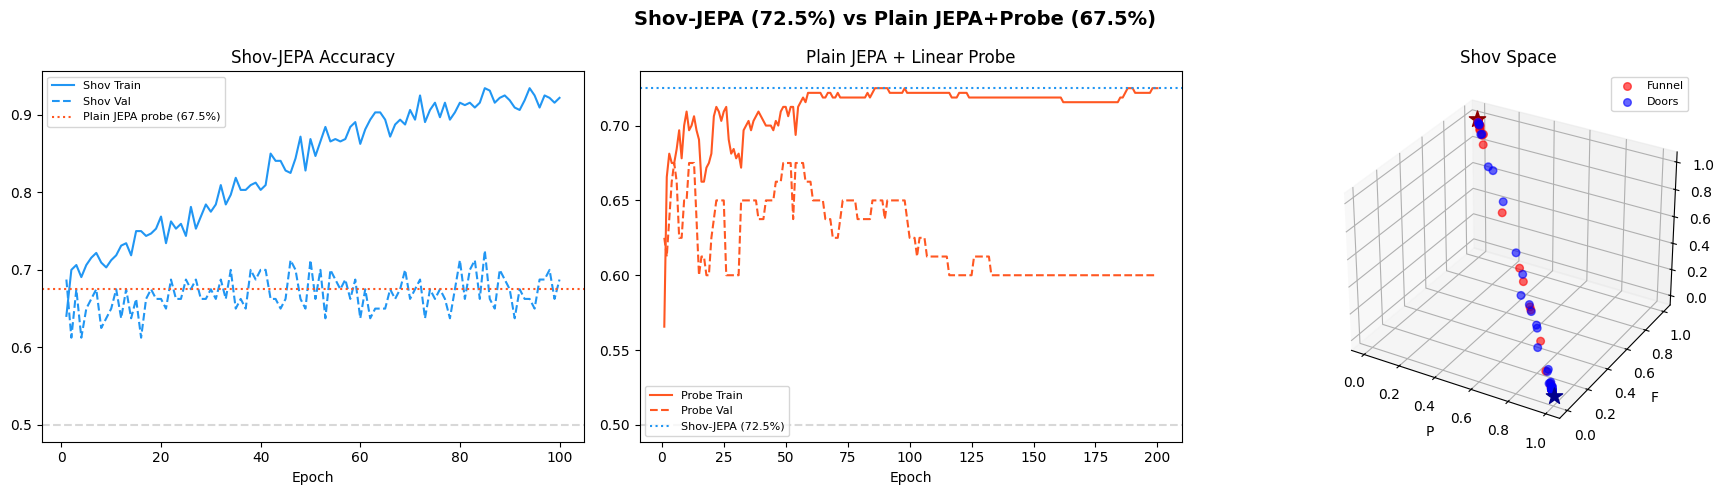

Funnel mean P/F/D: [0.36642173 0.63496417 0.63422877]
Doors  mean P/F/D: [0.71714896 0.28560224 0.28408316]


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Shov accuracy
axes[0].plot([h['ep'] for h in hs], [h['ta'] for h in hs], label='Shov Train', color='#2196F3')
axes[0].plot([h['ep'] for h in hs], [h['va'] for h in hs], label='Shov Val', color='#2196F3', ls='--')
axes[0].axhline(bp, color='#FF5722', ls=':', label=f'Plain JEPA probe ({bp:.1%})')
axes[0].axhline(0.5, color='gray', ls='--', alpha=0.3)
axes[0].set_title('Shov-JEPA Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=8)

# Linear probe accuracy
axes[1].plot([h['ep'] for h in hlp], [h['ta'] for h in hlp], label='Probe Train', color='#FF5722')
axes[1].plot([h['ep'] for h in hlp], [h['va'] for h in hlp], label='Probe Val', color='#FF5722', ls='--')
axes[1].axhline(bs, color='#2196F3', ls=':', label=f'Shov-JEPA ({bs:.1%})')
axes[1].axhline(0.5, color='gray', ls='--', alpha=0.3)
axes[1].set_title('Plain JEPA + Linear Probe'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8)

# 3D Shov space
coords = torch.cat(vco, 0).numpy()
fm=coords[:,3]==0; dm=coords[:,3]==1
ax3=fig.add_subplot(133,projection='3d')
axes[2].set_visible(False)
ax3.scatter(coords[fm,0],coords[fm,1],coords[fm,2],c='red',alpha=0.6,s=30,label='Funnel')
ax3.scatter(coords[dm,0],coords[dm,1],coords[dm,2],c='blue',alpha=0.6,s=30,label='Doors')
ax3.scatter([0],[1],[1],c='darkred',marker='*',s=150)
ax3.scatter([1],[0],[0],c='darkblue',marker='*',s=150)
ax3.set_xlabel('P'); ax3.set_ylabel('F'); ax3.set_zlabel('D')
ax3.set_title('Shov Space'); ax3.legend(fontsize=8)

plt.suptitle(f'Shov-JEPA ({bs:.1%}) vs Plain JEPA+Probe ({bp:.1%})', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Funnel mean P/F/D: {coords[fm,:3].mean(0)}')
print(f'Doors  mean P/F/D: {coords[dm,:3].mean(0)}')

## 7. Download

In [9]:
results = {
    'experiment': 'v5_shov_vs_plain_jepa',
    'shov_jepa': {'best_val': bs, 'history': hs,
                   'funnel_PFD': coords[fm,:3].mean(0).tolist(),
                   'doors_PFD': coords[dm,:3].mean(0).tolist()},
    'plain_jepa': {'best_probe_val': bp, 'pretrain_history': hp, 'probe_history': hlp},
    'all_results': {
        'v2_pixels': 0.688, 'v3_vh_mlp': 0.725,
        'v4_shov_grid': 0.7375,
        'v5_shov_jepa': bs, 'v5_plain_jepa_probe': bp
    }
}
with open(f'{DATA_DIR}/results_v5.json','w') as f: json.dump(results,f,indent=2)
import shutil
shutil.make_archive('/content/shov_v5','zip',DATA_DIR)
from google.colab import files
files.download('/content/shov_v5.zip')
print('Done!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


## Interpretation
| Result | Meaning |
|---|---|
| Shov > Plain | Prescribed axes = advantage when domain is known |
| Plain > Shov | Free representation finds what axes miss |
| Shov ~ Plain | Both valid, Shov gives interpretability for free |